[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/healthcareaibook/blob/main/vol%201%20notebooks/chapter_06/notebook_6_1_cnn_fundamentals.ipynb)

*Click the badge above to open this notebook in Google Colab (no setup required)*

---


# 6.1 CNN Fundamentals for Medical Imaging

## Learning Objectives
1. Understand convolution operations from first principles
2. Build a CNN from scratch (no high-level frameworks)
3. Visualize filters, feature maps, and activation patterns
4. Understand pooling, stride, and receptive fields
5. Apply CNNs to medical imaging tasks

## Clinical Context

**Journeys 3, 4, 5** all rely on Convolutional Neural Networks (CNNs):
- **Journey 3 (Jamal - Lung Nodules)**: CNN detects suspicious nodules in chest CT scans
- **Journey 4 (Elena - Brain Tumor)**: U-Net (CNN architecture) segments tumor boundaries
- **Journey 5 (Priya - Melanoma)**: CNN classifies skin lesions from dermatology images

**Why CNNs for Medical Imaging?**
- **Translation invariance**: Features detected anywhere in the image
- **Hierarchical features**: Low-level edges → mid-level textures → high-level shapes
- **Parameter efficiency**: Shared weights reduce overfitting
- **Spatial relationships**: Preserves pixel adjacency (unlike flattened MLPs)

---

## Setup

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.ndimage import convolve
from sklearn.datasets import load_sample_image
from skimage import filters, feature, transform
from skimage.util import random_noise
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Part 1: Understanding Convolution

### What is Convolution?

Convolution is a mathematical operation that applies a **filter (kernel)** to an image:

$$
(I * K)(x, y) = \sum_{i} \sum_{j} I(x+i, y+j) \cdot K(i, j)
$$

Where:
- $I$ = Input image
- $K$ = Kernel (filter)
- $*$ = Convolution operator

**Key Insight**: Instead of designing filters manually (like in classical computer vision), CNNs **learn** the best filters for the task!

In [2]:
def convolve2d_manual(image, kernel):
    """
    Manual implementation of 2D convolution (for educational purposes).
    In practice, use optimized libraries (scipy, pytorch, tensorflow).
    """
    kernel_height, kernel_width = kernel.shape
    image_height, image_width = image.shape

    # Output size (valid convolution, no padding)
    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1

    output = np.zeros((output_height, output_width))

    # Slide kernel across image
    for i in range(output_height):
        for j in range(output_width):
            # Extract image patch
            patch = image[i:i+kernel_height, j:j+kernel_width]
            # Element-wise multiplication and sum
            output[i, j] = np.sum(patch * kernel)

    return output

# Test with simple example
test_image = np.array([
    [1, 2, 3, 0],
    [0, 1, 2, 3],
    [3, 0, 1, 2],
    [2, 3, 0, 1]
])

# Simple 3x3 kernel (identity)
identity_kernel = np.array([
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0]
])

result = convolve2d_manual(test_image, identity_kernel)
print("Test convolution result (should match center values):")
print(result)
print("\n✓ Manual convolution implemented!")

Test convolution result (should match center values):
[[1. 2.]
 [0. 1.]]

✓ Manual convolution implemented!


### Classic Edge Detection Filters

Before deep learning, computer vision experts hand-designed filters for specific tasks:

In [3]:
# Define classic edge detection filters
filters_dict = {
    'Vertical Edges (Sobel)': np.array([[-1, 0, 1],
                                         [-2, 0, 2],
                                         [-1, 0, 1]]),

    'Horizontal Edges (Sobel)': np.array([[-1, -2, -1],
                                           [ 0,  0,  0],
                                           [ 1,  2,  1]]),

    'Sharpen': np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]]),

    'Gaussian Blur': np.array([[1, 2, 1],
                               [2, 4, 2],
                               [1, 2, 1]]) / 16,

    'Edge Detection (Laplacian)': np.array([[ 0,  1,  0],
                                             [ 1, -4,  1],
                                             [ 0,  1,  0]])
}

print("Classic Computer Vision Filters:")
for name, kernel in filters_dict.items():
    print(f"\n{name}:")
    print(kernel)

Classic Computer Vision Filters:

Vertical Edges (Sobel):
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]

Horizontal Edges (Sobel):
[[-1 -2 -1]
 [ 0  0  0]
 [ 1  2  1]]

Sharpen:
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]

Gaussian Blur:
[[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]

Edge Detection (Laplacian):
[[ 0  1  0]
 [ 1 -4  1]
 [ 0  1  0]]


### Generate Synthetic Medical Image

Let's create a simple synthetic "chest X-ray" to visualize filter effects:

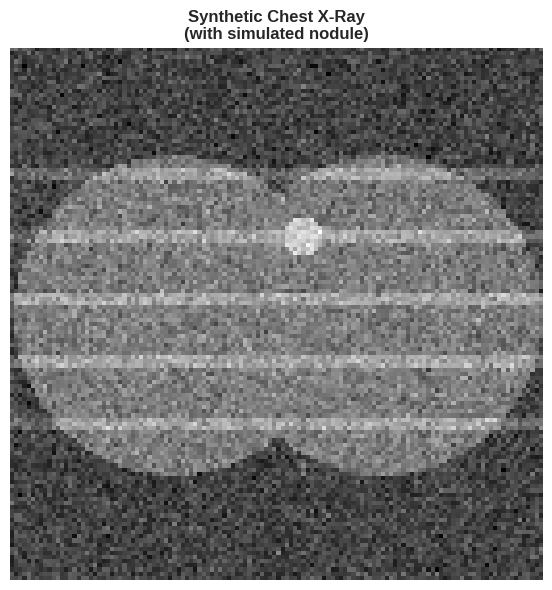

Image shape: (128, 128)
Pixel value range: [0.058, 0.966]


In [4]:
def create_synthetic_xray(size=128):
    """
    Create a synthetic chest X-ray-like image for demonstration.
    Includes: background, rib-like structures, lung fields, potential nodule.
    """
    image = np.ones((size, size)) * 0.3  # Background

    # Add "lung fields" (darker regions)
    y, x = np.ogrid[:size, :size]
    center_y, center_x = size // 2, size // 2

    # Left lung
    mask_left = (x - center_x + 25)**2 + (y - center_y)**2 < (size * 0.3)**2
    image[mask_left] = 0.5

    # Right lung
    mask_right = (x - center_x - 25)**2 + (y - center_y)**2 < (size * 0.3)**2
    image[mask_right] = 0.5

    # Add "ribs" (horizontal bright lines)
    for rib_y in range(30, size - 30, 15):
        image[rib_y-1:rib_y+2, :] += 0.15

    # Add small "nodule" (suspicious finding)
    nodule_y, nodule_x = 45, 70
    nodule_mask = (x - nodule_x)**2 + (y - nodule_y)**2 < 25
    image[nodule_mask] = 0.8

    # Add realistic noise
    image = random_noise(image, mode='gaussian', var=0.005)

    return np.clip(image, 0, 1)

# Create synthetic X-ray
xray_image = create_synthetic_xray(128)

plt.figure(figsize=(6, 6))
plt.imshow(xray_image, cmap='gray')
plt.title('Synthetic Chest X-Ray\n(with simulated nodule)', fontsize=12, weight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Image shape: {xray_image.shape}")
print(f"Pixel value range: [{xray_image.min():.3f}, {xray_image.max():.3f}]")

### Apply Filters to Medical Image

Let's see how different filters respond to our synthetic X-ray:

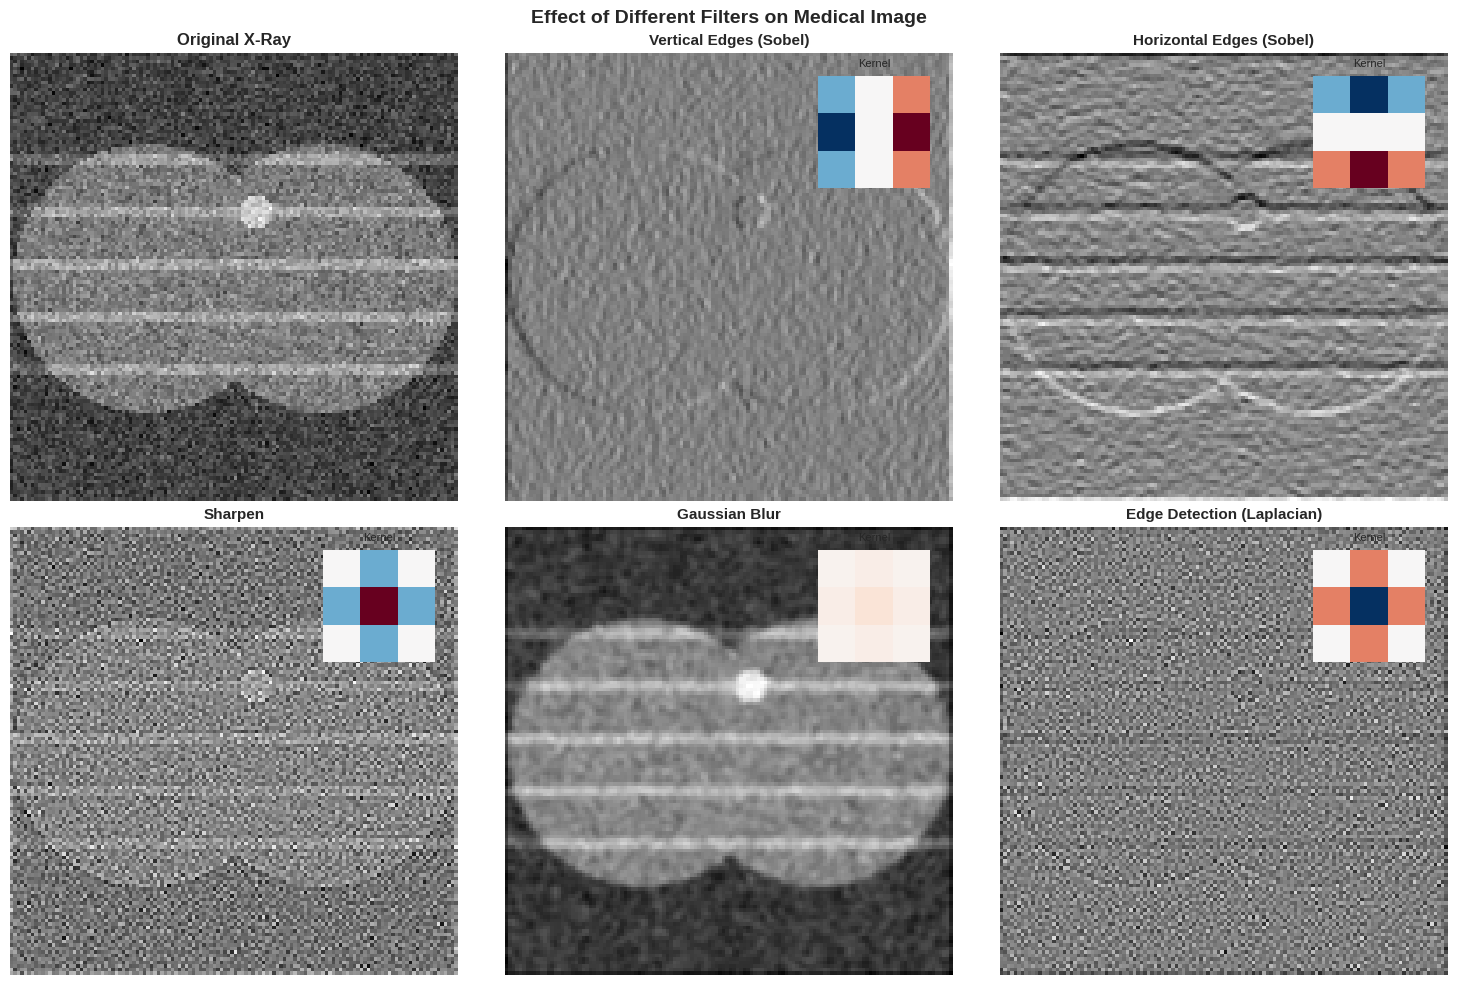


🔍 Observations:
- Vertical Sobel: Highlights vertical structures (lung boundaries)
- Horizontal Sobel: Highlights horizontal structures (ribs)
- Sharpen: Enhances edges and fine details (useful for nodule detection)
- Gaussian Blur: Smooths noise (preprocessing step)
- Laplacian: Detects regions of rapid intensity change (edges, boundaries)


In [5]:
# Apply all filters to the X-ray image
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# Original image
axes[0].imshow(xray_image, cmap='gray')
axes[0].set_title('Original X-Ray', fontsize=12, weight='bold')
axes[0].axis('off')

# Apply each filter
for idx, (filter_name, kernel) in enumerate(filters_dict.items(), start=1):
    # Use scipy for efficient convolution
    filtered = convolve(xray_image, kernel, mode='constant', cval=0.0)

    axes[idx].imshow(filtered, cmap='gray')
    axes[idx].set_title(filter_name, fontsize=11, weight='bold')
    axes[idx].axis('off')

    # Add kernel visualization as inset
    ax_inset = axes[idx].inset_axes([0.7, 0.7, 0.25, 0.25])
    ax_inset.imshow(kernel, cmap='RdBu_r', vmin=-2, vmax=2)
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax_inset.set_title('Kernel', fontsize=8)

plt.suptitle('Effect of Different Filters on Medical Image', fontsize=14, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n🔍 Observations:")
print("- Vertical Sobel: Highlights vertical structures (lung boundaries)")
print("- Horizontal Sobel: Highlights horizontal structures (ribs)")
print("- Sharpen: Enhances edges and fine details (useful for nodule detection)")
print("- Gaussian Blur: Smooths noise (preprocessing step)")
print("- Laplacian: Detects regions of rapid intensity change (edges, boundaries)")

## Part 2: Building a Simple CNN Layer

### CNN Layer Components

A standard CNN layer consists of:
1. **Convolution**: Apply learned filters
2. **Activation**: Non-linear transformation (ReLU)
3. **Pooling**: Downsample to reduce parameters

Let's implement each from scratch:

In [6]:
class SimpleConvLayer:
    """
    Simple convolutional layer implementation (educational purposes).
    In practice, use PyTorch/TensorFlow for GPU acceleration.
    """

    def __init__(self, num_filters=8, kernel_size=3):
        self.num_filters = num_filters
        self.kernel_size = kernel_size

        # Initialize random filters (in real CNNs, these are learned!)
        self.filters = np.random.randn(num_filters, kernel_size, kernel_size) * 0.1
        print(f"Initialized {num_filters} filters of size {kernel_size}x{kernel_size}")

    def convolve(self, image):
        """
        Apply all filters to the input image.
        Returns: feature_maps with shape (num_filters, height, width)
        """
        feature_maps = []

        for i, kernel in enumerate(self.filters):
            # Convolve image with this filter
            feature_map = convolve(image, kernel, mode='constant', cval=0.0)
            feature_maps.append(feature_map)

        return np.array(feature_maps)

    def relu(self, x):
        """ReLU activation: f(x) = max(0, x)"""
        return np.maximum(0, x)

    def max_pooling(self, feature_maps, pool_size=2):
        """
        Max pooling: take maximum value in each pool_size x pool_size window.
        Reduces spatial dimensions by factor of pool_size.
        """
        num_filters, height, width = feature_maps.shape

        # New dimensions after pooling
        new_height = height // pool_size
        new_width = width // pool_size

        pooled = np.zeros((num_filters, new_height, new_width))

        for f in range(num_filters):
            for i in range(new_height):
                for j in range(new_width):
                    # Extract pool window
                    i_start, i_end = i * pool_size, (i + 1) * pool_size
                    j_start, j_end = j * pool_size, (j + 1) * pool_size
                    window = feature_maps[f, i_start:i_end, j_start:j_end]

                    # Take maximum
                    pooled[f, i, j] = np.max(window)

        return pooled

    def forward(self, image, apply_relu=True, apply_pooling=True):
        """Complete forward pass: convolution → ReLU → pooling"""
        # 1. Convolution
        feature_maps = self.convolve(image)

        # 2. Activation (ReLU)
        if apply_relu:
            feature_maps = self.relu(feature_maps)

        # 3. Pooling
        if apply_pooling:
            feature_maps = self.max_pooling(feature_maps, pool_size=2)

        return feature_maps

# Initialize a simple CNN layer
conv_layer = SimpleConvLayer(num_filters=8, kernel_size=3)

# Apply to our X-ray image
feature_maps = conv_layer.forward(xray_image)

print(f"\nInput image shape: {xray_image.shape}")
print(f"Output feature maps shape: {feature_maps.shape}")
print(f"Spatial reduction: {xray_image.shape[0]} → {feature_maps.shape[1]} (due to pooling)")
print(f"Number of feature channels: {feature_maps.shape[0]}")

Initialized 8 filters of size 3x3

Input image shape: (128, 128)
Output feature maps shape: (8, 64, 64)
Spatial reduction: 128 → 64 (due to pooling)
Number of feature channels: 8


### Visualize Feature Maps

**Key Insight**: Each filter learns to detect different features!

Early CNN layers typically learn:
- **Layer 1**: Edges, gradients, colors
- **Layer 2-3**: Textures, patterns
- **Layer 4-5**: Object parts (e.g., "rib cage", "nodule-like shape")
- **Final layers**: Complete objects/diagnoses

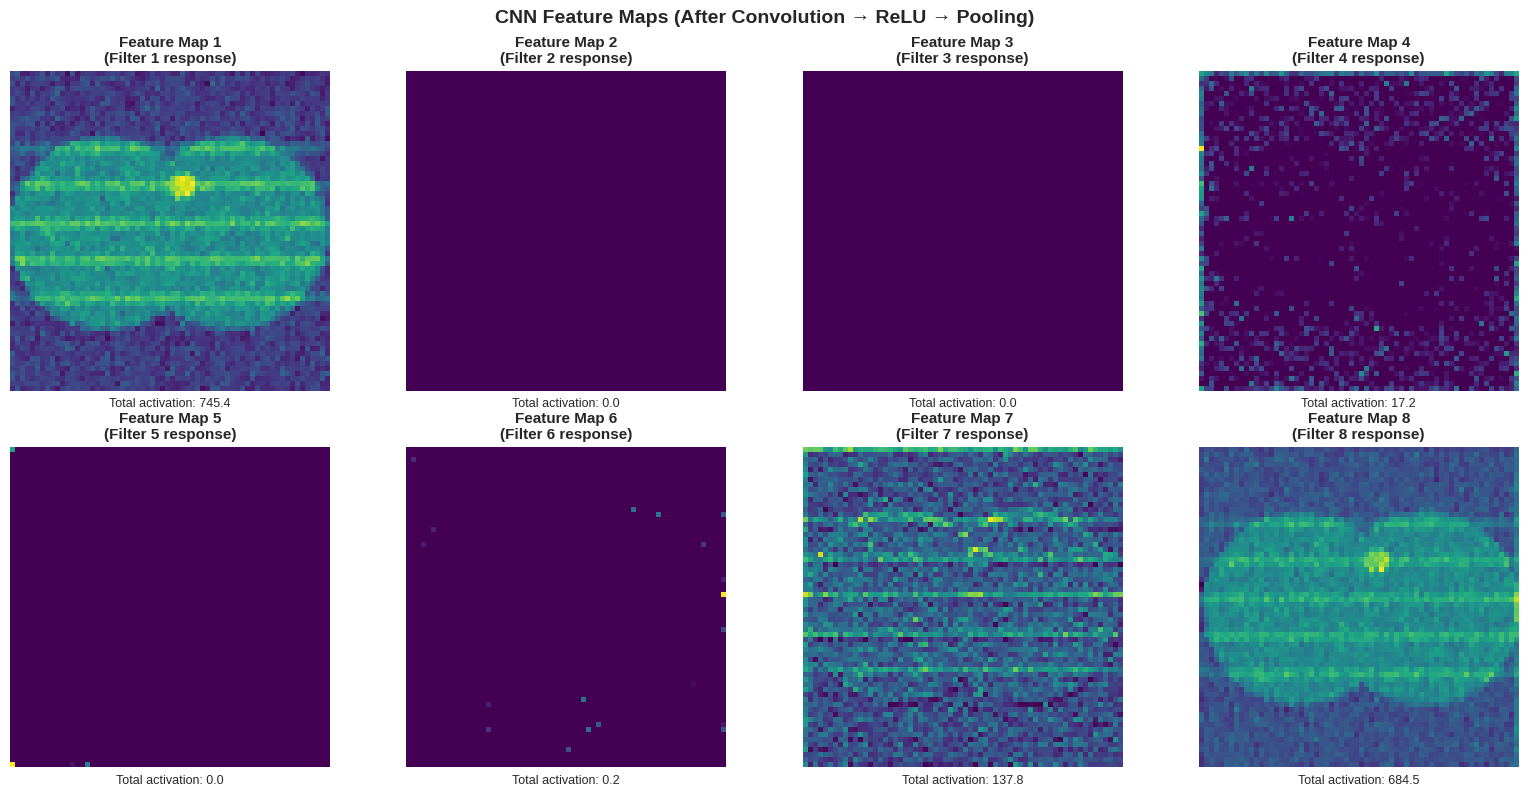


🔍 Interpretation:
- Bright regions = strong activation (filter detected relevant pattern)
- Dark regions = weak/no activation (pattern not present)
- Different filters activate on different image features
- This is how CNNs build hierarchical representations!


In [7]:
# Visualize all 8 feature maps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i in range(8):
    axes[i].imshow(feature_maps[i], cmap='viridis')
    axes[i].set_title(f'Feature Map {i+1}\n(Filter {i+1} response)', fontsize=11, weight='bold')
    axes[i].axis('off')

    # Show which parts of the image activated this filter
    activation_strength = np.sum(feature_maps[i])
    axes[i].text(0.5, -0.05, f'Total activation: {activation_strength:.1f}',
                 transform=axes[i].transAxes, ha='center', fontsize=9)

plt.suptitle('CNN Feature Maps (After Convolution → ReLU → Pooling)',
             fontsize=14, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n🔍 Interpretation:")
print("- Bright regions = strong activation (filter detected relevant pattern)")
print("- Dark regions = weak/no activation (pattern not present)")
print("- Different filters activate on different image features")
print("- This is how CNNs build hierarchical representations!")

### Visualize Learned Filters

Let's look at what the filters themselves look like:

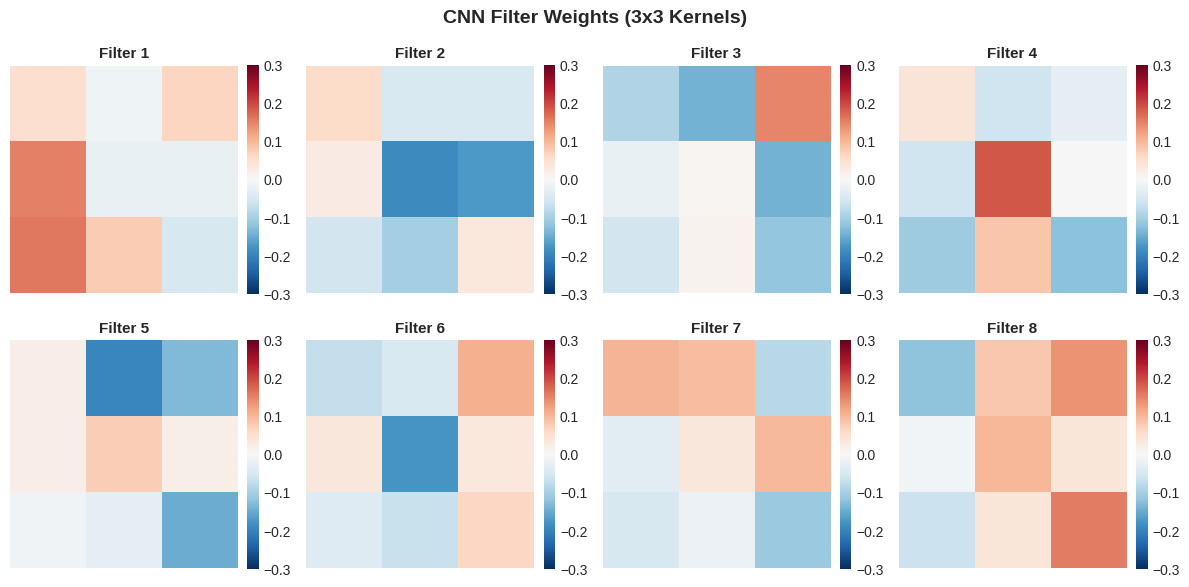


🎯 Note:
- In this example, filters are randomly initialized
- In a trained CNN, these would be optimized to detect useful features
- Red = positive weights, Blue = negative weights


In [8]:
# Visualize the learned filters
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for i in range(8):
    im = axes[i].imshow(conv_layer.filters[i], cmap='RdBu_r', vmin=-0.3, vmax=0.3)
    axes[i].set_title(f'Filter {i+1}', fontsize=11, weight='bold')
    axes[i].axis('off')

    # Add colorbar to each subplot
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.suptitle('CNN Filter Weights (3x3 Kernels)', fontsize=14, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n🎯 Note:")
print("- In this example, filters are randomly initialized")
print("- In a trained CNN, these would be optimized to detect useful features")
print("- Red = positive weights, Blue = negative weights")

## Part 3: Understanding Pooling

### Why Pooling?

**Pooling** reduces spatial dimensions while retaining important information:
- **Reduces parameters**: Less overfitting, faster computation
- **Translation invariance**: Small shifts don't change output
- **Increases receptive field**: Each neuron "sees" larger input region

**Max Pooling** takes the maximum value in each window:

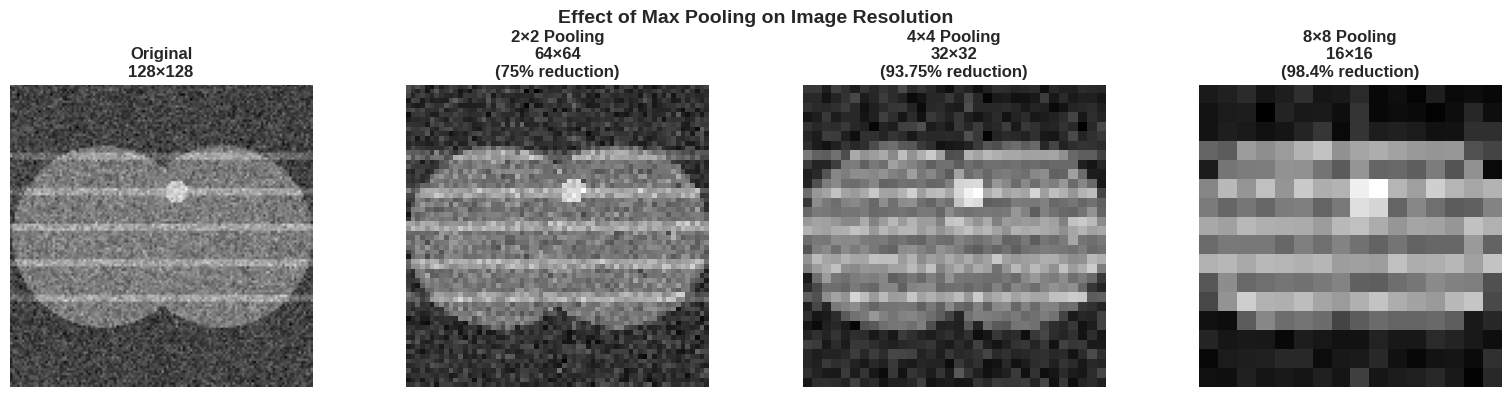


⚖️ Pooling Trade-offs:
✓ Reduces computational cost (fewer parameters)
✓ Provides translation invariance
✓ Reduces overfitting
✗ Loses spatial resolution (problematic for segmentation tasks!)

Note: U-Net (Journey 4) uses skip connections to recover lost spatial info!


In [9]:
# Demonstrate pooling effect
def visualize_pooling(image, pool_size=2):
    """
    Visualize the effect of max pooling.
    """
    height, width = image.shape
    new_height = height // pool_size
    new_width = width // pool_size

    pooled = np.zeros((new_height, new_width))

    for i in range(new_height):
        for j in range(new_width):
            window = image[i*pool_size:(i+1)*pool_size,
                          j*pool_size:(j+1)*pool_size]
            pooled[i, j] = np.max(window)

    return pooled

# Apply different pooling sizes
pooled_2x2 = visualize_pooling(xray_image, pool_size=2)
pooled_4x4 = visualize_pooling(xray_image, pool_size=4)
pooled_8x8 = visualize_pooling(xray_image, pool_size=8)

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(xray_image, cmap='gray')
axes[0].set_title(f'Original\n{xray_image.shape[0]}×{xray_image.shape[1]}',
                  fontsize=12, weight='bold')
axes[0].axis('off')

axes[1].imshow(pooled_2x2, cmap='gray')
axes[1].set_title(f'2×2 Pooling\n{pooled_2x2.shape[0]}×{pooled_2x2.shape[1]}\n(75% reduction)',
                  fontsize=12, weight='bold')
axes[1].axis('off')

axes[2].imshow(pooled_4x4, cmap='gray')
axes[2].set_title(f'4×4 Pooling\n{pooled_4x4.shape[0]}×{pooled_4x4.shape[1]}\n(93.75% reduction)',
                  fontsize=12, weight='bold')
axes[2].axis('off')

axes[3].imshow(pooled_8x8, cmap='gray')
axes[3].set_title(f'8×8 Pooling\n{pooled_8x8.shape[0]}×{pooled_8x8.shape[1]}\n(98.4% reduction)',
                  fontsize=12, weight='bold')
axes[3].axis('off')

plt.suptitle('Effect of Max Pooling on Image Resolution', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n⚖️ Pooling Trade-offs:")
print("✓ Reduces computational cost (fewer parameters)")
print("✓ Provides translation invariance")
print("✓ Reduces overfitting")
print("✗ Loses spatial resolution (problematic for segmentation tasks!)")
print("\nNote: U-Net (Journey 4) uses skip connections to recover lost spatial info!")

## Part 4: Receptive Fields

### What is a Receptive Field?

The **receptive field** of a neuron is the region of the input image that influences its activation.

**Key Insight**: As we stack CNN layers, receptive fields grow exponentially!

$$
\text{Receptive Field}_L = \text{RF}_{L-1} + (k - 1) \times \prod_{i=1}^{L-1} s_i
$$

Where:
- $k$ = kernel size
- $s_i$ = stride at layer $i$

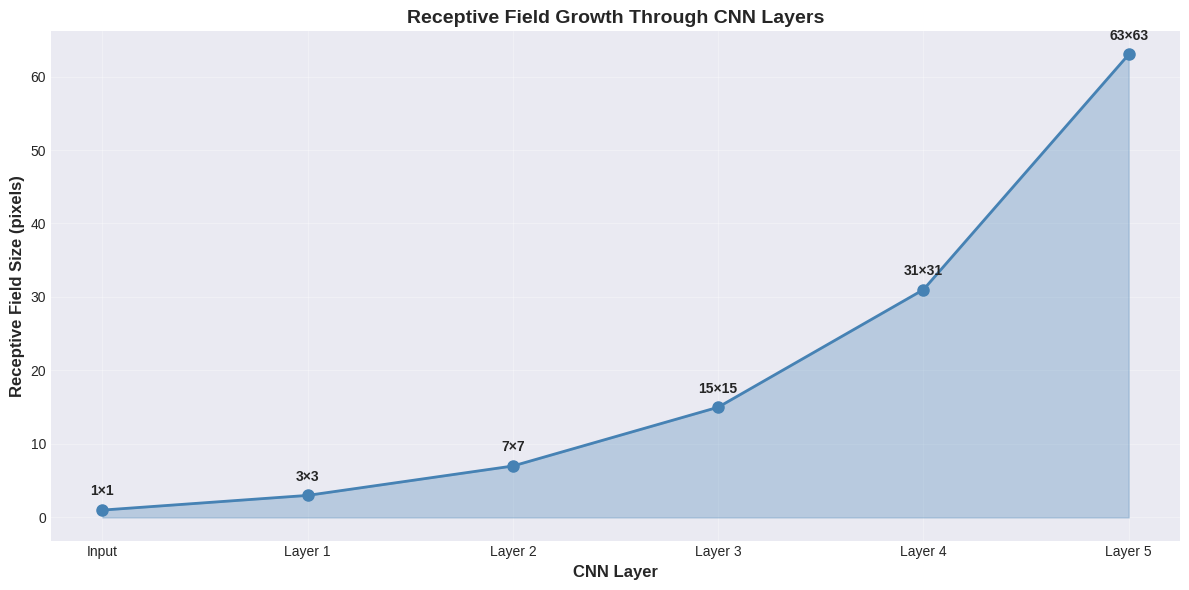


Receptive Field Sizes:
Input: 1×1 pixels
Layer 1: 3×3 pixels
Layer 2: 7×7 pixels
Layer 3: 15×15 pixels
Layer 4: 31×31 pixels
Layer 5: 63×63 pixels

🎯 Clinical Implications:
- Layer 1 (RF=3×3): Detects edges, textures
- Layer 2 (RF=7×7): Detects small structures (vessels, microcalcifications)
- Layer 3 (RF=15×15): Detects nodules, lesions
- Layer 4 (RF=31×31): Detects organs, large masses
- Layer 5 (RF=47×47): Holistic patterns, anatomical context


In [10]:
def calculate_receptive_field(layers):
    """
    Calculate receptive field size for a sequence of CNN layers.

    Args:
        layers: List of (kernel_size, stride, pooling_stride) tuples

    Returns:
        List of receptive field sizes after each layer
    """
    rf = 1  # Initial receptive field
    jump = 1  # Current jump/stride
    receptive_fields = [rf]

    for kernel_size, conv_stride, pool_stride in layers:
        # After convolution
        rf = rf + (kernel_size - 1) * jump
        jump = jump * conv_stride

        # After pooling (if present)
        if pool_stride > 1:
            jump = jump * pool_stride

        receptive_fields.append(rf)

    return receptive_fields

# Example: typical CNN architecture
architecture = [
    (3, 1, 2),  # Layer 1: 3×3 conv, stride=1, 2×2 pooling
    (3, 1, 2),  # Layer 2: 3×3 conv, stride=1, 2×2 pooling
    (3, 1, 2),  # Layer 3: 3×3 conv, stride=1, 2×2 pooling
    (3, 1, 2),  # Layer 4: 3×3 conv, stride=1, 2×2 pooling
    (3, 1, 1),  # Layer 5: 3×3 conv, stride=1, no pooling
]

rf_sizes = calculate_receptive_field(architecture)

# Visualize receptive field growth
fig, ax = plt.subplots(figsize=(12, 6))

layers_labels = ['Input'] + [f'Layer {i+1}' for i in range(len(architecture))]
ax.plot(layers_labels, rf_sizes, marker='o', linewidth=2, markersize=8, color='steelblue')
ax.fill_between(range(len(rf_sizes)), rf_sizes, alpha=0.3, color='steelblue')

ax.set_xlabel('CNN Layer', fontsize=12, weight='bold')
ax.set_ylabel('Receptive Field Size (pixels)', fontsize=12, weight='bold')
ax.set_title('Receptive Field Growth Through CNN Layers', fontsize=14, weight='bold')
ax.grid(True, alpha=0.3)

# Annotate values
for i, (label, rf) in enumerate(zip(layers_labels, rf_sizes)):
    ax.text(i, rf + 2, f'{rf}×{rf}', ha='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

print("\nReceptive Field Sizes:")
for i, (label, rf) in enumerate(zip(layers_labels, rf_sizes)):
    print(f"{label}: {rf}×{rf} pixels")

print("\n🎯 Clinical Implications:")
print("- Layer 1 (RF=3×3): Detects edges, textures")
print("- Layer 2 (RF=7×7): Detects small structures (vessels, microcalcifications)")
print("- Layer 3 (RF=15×15): Detects nodules, lesions")
print("- Layer 4 (RF=31×31): Detects organs, large masses")
print("- Layer 5 (RF=47×47): Holistic patterns, anatomical context")

## Part 5: Comparing Different Activation Functions

CNNs use **non-linear activation functions** to learn complex patterns:

1. **ReLU**: $f(x) = \max(0, x)$
2. **Sigmoid**: $f(x) = \frac{1}{1 + e^{-x}}$
3. **Tanh**: $f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
4. **Leaky ReLU**: $f(x) = \max(0.01x, x)$

In [ ]:
# Define activation functions
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

# Plot activation functions
x = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

activations = [
    (relu, 'ReLU', 'steelblue'),
    (sigmoid, 'Sigmoid', 'coral'),
    (tanh, 'Tanh', 'mediumseagreen'),
    (leaky_relu, 'Leaky ReLU', 'purple')
]

for ax, (func, name, color) in zip(axes, activations):
    y = func(x)
    ax.plot(x, y, linewidth=2.5, color=color)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.3)
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.3)
    ax.set_title(name, fontsize=12, weight='bold')
    ax.set_xlabel('Input', fontsize=10)
    ax.set_ylabel('Output', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-1.5, 5])

plt.suptitle('Common Activation Functions in CNNs', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Activation Function Comparison:")
print("\nReLU (Most Common):")
print("  ✓ Fast to compute")
print("  ✓ Helps with vanishing gradient problem")
print("  ✗ Dead neurons (if input always negative)")
print("\nSigmoid:")
print("  ✓ Output range [0, 1] (useful for probabilities)")
print("  ✗ Vanishing gradients for extreme values")
print("  ✗ Not zero-centered")
print("\nTanh:")
print("  ✓ Zero-centered (better than sigmoid)")
print("  ✗ Still suffers from vanishing gradients")
print("\nLeaky ReLU:")
print("  ✓ Fixes 'dying ReLU' problem")
print("  ✓ Small gradient for negative inputs")

## Part 6: Complete CNN Architecture Example

Let's build a simple CNN for binary classification (nodule detection):

In [ ]:
class SimpleCNN:
    """
    Simple CNN for binary medical image classification.
    Architecture: Conv → ReLU → Pool → Conv → ReLU → Pool → Flatten → Dense
    """

    def __init__(self):
        # Layer 1
        self.conv1 = SimpleConvLayer(num_filters=16, kernel_size=3)

        # Layer 2
        self.conv2 = SimpleConvLayer(num_filters=32, kernel_size=3)

        print("\n✓ SimpleCNN initialized!")
        print("Architecture:")
        print("  Input (128×128×1)")
        print("  → Conv1 (16 filters, 3×3) → ReLU → MaxPool(2×2)")
        print("  → Conv2 (32 filters, 3×3) → ReLU → MaxPool(2×2)")
        print("  → Flatten → Dense → Output (2 classes)")

    def forward(self, image):
        """
        Forward pass through the network.
        """
        # Layer 1: Conv → ReLU → Pool
        x = self.conv1.forward(image)
        print(f"After Conv1: {x.shape}")

        # Layer 2: Conv → ReLU → Pool
        # Apply conv2 to each channel from conv1
        conv2_outputs = []
        for i in range(x.shape[0]):
            output = self.conv2.forward(x[i])
            conv2_outputs.append(output)

        x = np.array(conv2_outputs)
        print(f"After Conv2: {x.shape}")

        # Flatten
        x_flat = x.flatten()
        print(f"After Flatten: {x_flat.shape}")

        # In a real CNN, this would go through fully connected layers
        # For simplicity, we'll just return the flattened features
        return x, x_flat

# Initialize and run CNN
cnn = SimpleCNN()

print("\n" + "="*60)
print("Running forward pass...")
print("="*60)

feature_maps, features = cnn.forward(xray_image)

print("\n" + "="*60)
print(f"Final feature vector size: {features.shape[0]} features")
print("These features would feed into a classifier (softmax/sigmoid)")
print("="*60)

### Visualize Multi-Layer Feature Maps

Let's see how representations become more abstract in deeper layers:

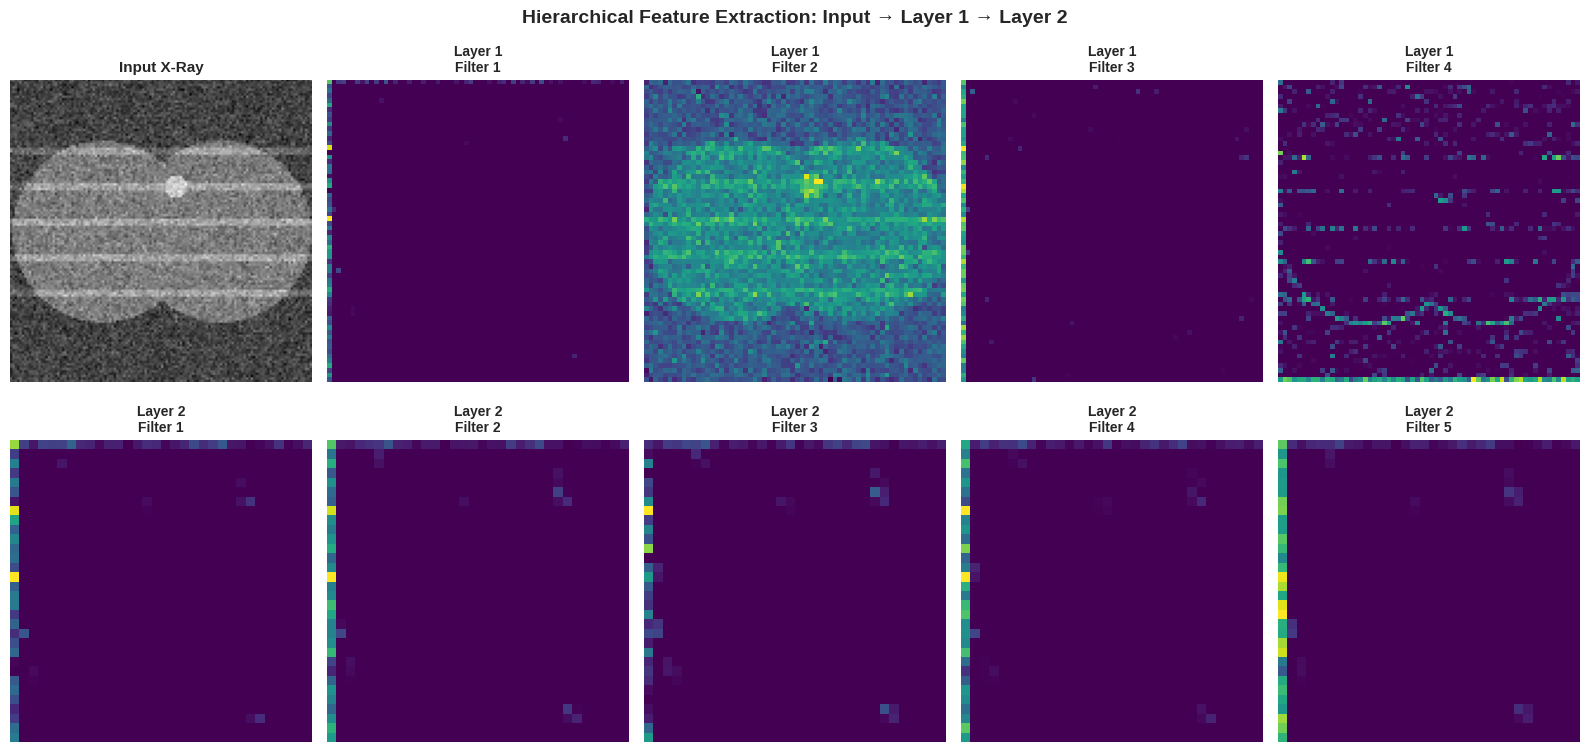


🧠 Hierarchical Learning:
- Layer 1: Low-level features (edges, textures, gradients)
- Layer 2: Mid-level features (corners, patterns, shapes)
- Deeper layers (not shown): High-level features (nodules, organs, pathology)

This is how CNNs build understanding from pixels to diagnosis!


In [ ]:
# Get intermediate feature maps
layer1_features = cnn.conv1.forward(xray_image)

# Visualize subset of Layer 1 and Layer 2 features
fig = plt.figure(figsize=(16, 8))

# Original image
ax0 = plt.subplot(2, 5, 1)
ax0.imshow(xray_image, cmap='gray')
ax0.set_title('Input X-Ray', fontsize=11, weight='bold')
ax0.axis('off')

# Layer 1 features (first 4)
for i in range(4):
    ax = plt.subplot(2, 5, i+2)
    ax.imshow(layer1_features[i], cmap='viridis')
    ax.set_title(f'Layer 1\nFilter {i+1}', fontsize=10, weight='bold')
    ax.axis('off')

# Layer 2 features (first 5)
for i in range(5):
    ax = plt.subplot(2, 5, i+6)
    # Layer 2 features from first channel of layer 1
    layer2_single = cnn.conv2.forward(layer1_features[0])
    ax.imshow(layer2_single[i], cmap='viridis')
    ax.set_title(f'Layer 2\nFilter {i+1}', fontsize=10, weight='bold')
    ax.axis('off')

plt.suptitle('Hierarchical Feature Extraction: Input → Layer 1 → Layer 2',
             fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n🧠 Hierarchical Learning:")
print("- Layer 1: Low-level features (edges, textures, gradients)")
print("- Layer 2: Mid-level features (corners, patterns, shapes)")
print("- Deeper layers (not shown): High-level features (nodules, organs, pathology)")
print("\nThis is how CNNs build understanding from pixels to diagnosis!")

## Part 7: Parameter Counting

### Why CNNs are Efficient

CNNs have far fewer parameters than fully-connected networks due to **weight sharing**!

In [ ]:
def count_parameters(input_size, architecture):
    """
    Count parameters for CNN vs fully-connected network.

    Args:
        input_size: (height, width, channels)
        architecture: List of (num_filters, kernel_size, pool_size) tuples
    """
    h, w, c = input_size
    cnn_params = 0
    current_channels = c
    current_size = h * w

    print("CNN Parameter Count:")
    print("="*60)

    for i, (num_filters, kernel_size, pool_size) in enumerate(architecture, 1):
        # Convolution parameters: (kernel_h × kernel_w × in_channels + 1_bias) × num_filters
        conv_params = (kernel_size * kernel_size * current_channels + 1) * num_filters
        cnn_params += conv_params

        print(f"Layer {i} (Conv):")
        print(f"  Filters: {num_filters}, Kernel: {kernel_size}×{kernel_size}")
        print(f"  Parameters: {conv_params:,}")

        # Update for next layer
        current_channels = num_filters
        current_size = current_size // (pool_size ** 2)  # After pooling

    print("="*60)
    print(f"Total CNN parameters: {cnn_params:,}")

    # Compare with fully-connected network
    fc_params = (h * w * c) * 100  # First hidden layer with 100 neurons

    print("\n" + "="*60)
    print("Comparison with Fully-Connected Network:")
    print("="*60)
    print(f"FC first layer (input → 100 neurons): {fc_params:,} parameters")
    print(f"CNN all layers: {cnn_params:,} parameters")
    print(f"\nParameter reduction: {fc_params / cnn_params:.1f}x fewer parameters!")

    return cnn_params, fc_params

# Example: simple CNN for 128×128 grayscale images
input_size = (128, 128, 1)
architecture = [
    (16, 3, 2),  # 16 filters, 3×3, 2×2 pooling
    (32, 3, 2),  # 32 filters, 3×3, 2×2 pooling
    (64, 3, 2),  # 64 filters, 3×3, 2×2 pooling
]

cnn_params, fc_params = count_parameters(input_size, architecture)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(['CNN\n(3 layers)', 'Fully-Connected\n(1 layer, 100 neurons)'],
              [cnn_params, fc_params], color=['steelblue', 'coral'])

ax.set_ylabel('Number of Parameters', fontsize=12, weight='bold')
ax.set_title('Parameter Efficiency: CNN vs Fully-Connected', fontsize=14, weight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

# Annotate bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

print("\n🎯 Key Insight:")
print("CNNs achieve better performance with FAR fewer parameters due to:")
print("1. Weight sharing (same filter applied everywhere)")
print("2. Local connectivity (neurons only connect to nearby pixels)")
print("3. Pooling (reduces spatial dimensions)")

## Part 8: Clinical Connections

### How CNNs Work in Real Medical AI Systems

Let's trace how CNNs process medical images in our clinical journeys:

In [ ]:
# Create visualization of CNN processing pipeline
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Journey 3: Lung Nodule Detection
ax1 = axes[0]
stages = ['CT Scan\n(Input)', 'Layer 1\n(Edges)', 'Layer 2-3\n(Textures)',
          'Layer 4-5\n(Nodule shapes)', 'Classifier\n(Nodule/Not)']
y_pos = np.arange(len(stages))
colors = ['lightblue', 'skyblue', 'steelblue', 'darkblue', 'darkgreen']

ax1.barh(y_pos, [1]*len(stages), color=colors, alpha=0.7)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(stages, fontsize=11)
ax1.set_xlim(0, 1.2)
ax1.set_xlabel('CNN Processing Flow →', fontsize=11, weight='bold')
ax1.set_title('Journey 3 (Jamal): Lung Nodule Detection CNN',
              fontsize=12, weight='bold', pad=10)
ax1.set_xticks([])

# Add arrows
for i in range(len(stages)-1):
    ax1.annotate('', xy=(1.1, i+1), xytext=(1.1, i),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Journey 4: Brain Tumor Segmentation (U-Net)
ax2 = axes[1]
stages_unet = ['MRI Scan\n(Input)', 'Encoder\n(Downsample)', 'Bottleneck\n(Deep features)',
               'Decoder\n(Upsample)', 'Pixel-wise\nSegmentation']
colors_unet = ['lightcoral', 'coral', 'orangered', 'coral', 'darkgreen']

ax2.barh(y_pos, [1]*len(stages_unet), color=colors_unet, alpha=0.7)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(stages_unet, fontsize=11)
ax2.set_xlim(0, 1.2)
ax2.set_xlabel('U-Net Processing Flow →', fontsize=11, weight='bold')
ax2.set_title('Journey 4 (Elena): Brain Tumor Segmentation (U-Net)',
              fontsize=12, weight='bold', pad=10)
ax2.set_xticks([])

for i in range(len(stages_unet)-1):
    ax2.annotate('', xy=(1.1, i+1), xytext=(1.1, i),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Add skip connection annotation
ax2.annotate('Skip\nConnections', xy=(0.5, 3), xytext=(0.5, 1),
            arrowprops=dict(arrowstyle='<->', lw=2, color='purple', linestyle='--'),
            fontsize=10, weight='bold', color='purple', ha='center')

# Journey 5: Melanoma Classification
ax3 = axes[2]
stages_melanoma = ['Dermoscopy\nImage', 'Layer 1\n(Colors, edges)', 'Layer 2-3\n(ABCDE features)',
                   'Layer 4-5\n(Lesion patterns)', 'Classifier\n(Benign/Malignant)']
colors_melanoma = ['lightyellow', 'gold', 'orange', 'darkorange', 'darkred']

ax3.barh(y_pos, [1]*len(stages_melanoma), color=colors_melanoma, alpha=0.7)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(stages_melanoma, fontsize=11)
ax3.set_xlim(0, 1.2)
ax3.set_xlabel('CNN Processing Flow →', fontsize=11, weight='bold')
ax3.set_title('Journey 5 (Priya): Melanoma Classification CNN',
              fontsize=12, weight='bold', pad=10)
ax3.set_xticks([])

for i in range(len(stages_melanoma)-1):
    ax3.annotate('', xy=(1.1, i+1), xytext=(1.1, i),
                arrowprops=dict(arrowstyle='->', lw=2, color='black'))

plt.tight_layout()
plt.show()

print("\n🏥 Clinical Applications Summary:")
print("\nJourney 3 (Lung Nodules):")
print("  - Task: Binary classification (nodule vs non-nodule)")
print("  - Architecture: Standard CNN (VGG-like, ResNet)")
print("  - Output: Probability of malignancy")
print("\nJourney 4 (Brain Tumor):")
print("  - Task: Semantic segmentation (pixel-wise labels)")
print("  - Architecture: U-Net (encoder-decoder with skip connections)")
print("  - Output: Tumor boundary mask")
print("\nJourney 5 (Melanoma):")
print("  - Task: Binary classification (benign vs malignant)")
print("  - Architecture: CNN (EfficientNet, ResNet)")
print("  - Output: Malignancy risk score")

## Summary: Key Takeaways

### What We Learned

1. **Convolution Operation**
   - Mathematical operation applying filters to images
   - CNNs **learn** optimal filters (vs hand-designed in classical CV)
   - Weight sharing → parameter efficiency

2. **CNN Architecture Components**
   - **Convolution**: Extract local features with learned filters
   - **Activation (ReLU)**: Introduce non-linearity
   - **Pooling**: Downsample, increase receptive field, reduce parameters

3. **Hierarchical Feature Learning**
   - Layer 1: Low-level features (edges, textures)
   - Layer 2-3: Mid-level features (patterns, shapes)
   - Layer 4-5: High-level features (objects, pathology)
   - Final layers: Task-specific predictions

4. **Receptive Fields**
   - Grow exponentially with depth
   - Deeper layers "see" larger image regions
   - Critical for capturing context

5. **Parameter Efficiency**
   - CNNs have far fewer parameters than fully-connected networks
   - Weight sharing across spatial dimensions
   - Reduces overfitting, enables training on limited medical data

### Connections to Clinical Journeys

- **Journey 3 (Jamal)**: Standard CNN for nodule classification
- **Journey 4 (Elena)**: U-Net for precise tumor segmentation
- **Journey 5 (Priya)**: CNN for melanoma detection

### Real-World Considerations

**Advantages:**
- Translation invariance (detect features anywhere)
- Parameter efficiency (less overfitting)
- Hierarchical learning (low to high-level features)
- State-of-the-art performance on medical imaging

**Challenges:**
- Require large labeled datasets (expensive in healthcare)
- "Black box" nature (difficult to interpret)
- Sensitive to image quality and artifacts
- Domain shift (performance drops on different scanners/protocols)

**Mitigation Strategies:**
- Transfer learning from ImageNet/RadImageNet
- Data augmentation (see Notebook 6.4)
- Interpretability tools (GradCAM - see Notebook 6.7)
- Domain adaptation techniques

---

## Exercises

1. **Modify the CNN architecture**: Add a third convolutional layer and observe how receptive fields change. How does this affect the types of features that can be detected?

2. **Compare activation functions**: Implement the same CNN with different activation functions (ReLU, Sigmoid, Tanh, Leaky ReLU). Which performs best on medical images? Why?

3. **Design custom filters**: Create hand-designed filters for specific medical imaging tasks (e.g., rib detection in X-rays, vessel enhancement in angiography). Compare with learned CNN filters.

4. **Pooling alternatives**: Implement average pooling instead of max pooling. When might average pooling be preferable in medical imaging?

5. **Parameter analysis**: Calculate the total number of parameters for a ResNet-50 architecture. Compare with a standard CNN. What are the trade-offs?

6. **Receptive field design**: Design a CNN architecture where the final layer has a receptive field of at least 256×256 pixels. What architectural choices enable this?

7. **Clinical application**: Choose a medical imaging task (e.g., bone fracture detection, diabetic retinopathy screening) and design an appropriate CNN architecture. Justify your design decisions.

---

*This notebook is part of "AI in Healthcare" (Volume 1: Machine Learning Foundations)*  
*Full implementation and companion code available in the book repository*

**Next Steps:**
- **Notebook 6.3**: Image Preprocessing (normalization, windowing, CLAHE)
- **Notebook 6.4**: Data Augmentation (rotations, flips, elastic deformations)
- **Notebook 6.7**: GradCAM Interpretability (visualizing what CNNs learn)
- **Journeys 3-5**: Complete clinical implementations